##Universitetet i Sørøst-Norge

##Prosjekt i PY1010

##Kendal ADANC



In [2]:
#importerer pakker for dataanalyse og vusualisering

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#Skal les excel-filen som gitt opp på canvas
df = pd.read_excel("support_uke_24.xlsx", sheet_name =0)

#viser første radene for kolonnestruktur og innhold
df.head()

,Ukedag,Klokkeslett,Varighet,Tilfredshet
0,Mandag,08:04:16,00:07:12,NaN
1,Mandag,08:04:53,00:02:49,6.0
2,Mandag,08:06:31,00:08:36,NaN
3,Mandag,08:11:21,00:04:34,NaN
4,Mandag,08:20:46,00:07:38,NaN


In [4]:
#ensarter kollenavn for å unngå keyerror 
df.columns = [str(c).strip().capitalize()for c in df.columns]

#Konverterer klokkeslett fra text til time
df["Klokkeslett"] = pd.to_datetime(df["Klokkeslett"].astype(str)).dt.time

#Konverterer variughet fra tekst til timedelta
df["Varighet_td"] = pd.to_timedelta(df["Varighet"].astype(str))

#Lager varighet i minutter som tall float
df["Varighet_min"] = df["Varighet_td"].dt.total_seconds() / 60

#viser første radene for kolonnestruktur og innhold
df.head()

C:\Users\keno_\AppData\Local\Temp\ipykernel_100772\3714092310.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Klokkeslett"] = pd.to_datetime(df["Klokkeslett"].astype(str)).dt.time


,Ukedag,Klokkeslett,Varighet,Tilfredshet,Varighet_td,Varighet_min
0,Mandag,08:04:16,00:07:12,NaN,0 days 00:07:12,7.200000
1,Mandag,08:04:53,00:02:49,6.0,0 days 00:02:49,2.816667
2,Mandag,08:06:31,00:08:36,NaN,0 days 00:08:36,8.600000
3,Mandag,08:11:21,00:04:34,NaN,0 days 00:04:34,4.566667
4,Mandag,08:20:46,00:07:38,NaN,0 days 00:07:38,7.633333


In [5]:
## Trekker ut kollone som numpy-arrays ,skal gi ny navn som gitt oss på oppgavne

u_dag = df["Ukedag"].to_numpy() #ukedag tekst
kl_slett = df["Klokkeslett"].to_numpy() #klokkslett
varighet = df["Varighet_td"].to_numpy() #varighet men timedelta
score = df["Tilfredshet"].to_numpy() #tilfredshet

#kontroll

u_dag[:5], kl_slett[:5], varighet[:5], score[:15]


(array(['Mandag', 'Mandag', 'Mandag', 'Mandag', 'Mandag'], dtype=object),
 array([datetime.time(8, 4, 16), datetime.time(8, 4, 53),
        datetime.time(8, 6, 31), datetime.time(8, 11, 21),
        datetime.time(8, 20, 46)], dtype=object),
 array([432000000000, 169000000000, 516000000000, 274000000000,
        458000000000], dtype='timedelta64[ns]'),
 array([nan,  6., nan, nan, nan,  8., nan, nan, 10., nan, nan, nan, nan,
        nan, nan]))

In [6]:
##Rekkefølge på ukedager

rekkefolge = ["Mandag", "Tirsdag", "Onsdag", "Torsdag", "Fredag"]

#Teller hvor mange henvedelser som kommer inn hver dag og reinndekserer for fast rekkefølge

counts_per_day = pd.Series(u_dag).value_counts().reindex(rekkefolge, fill_value=0)

#Viser tellere og en ransk sum kontrol

counts_per_day, counts_per_day.sum(), len(df)


(Mandag     51
 Tirsdag    44
 Onsdag     45
 Torsdag    35
 Fredag     42
 Name: count, dtype: int64,
 np.int64(217),
 217)

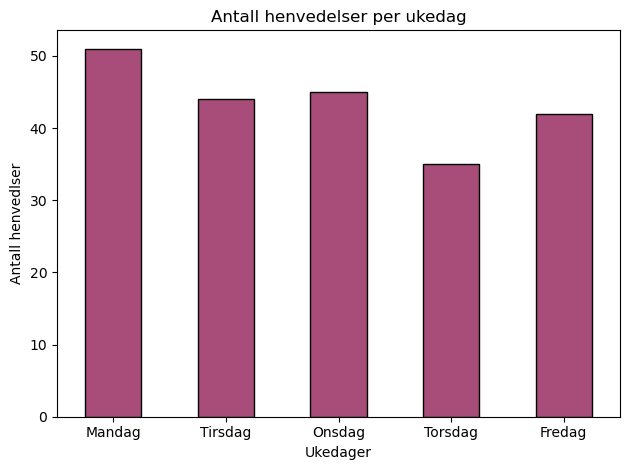

In [7]:
plt.Figure()
counts_per_day.plot(kind="bar", color="#A84C7A", edgecolor = "black")
plt.title("Antall henvedelser per ukedag") 
plt.xlabel("Ukedager")
plt.ylabel("Antall henvedlser")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

In [ ]:
## Minste og maks samtaletid for uke 24 

min_td = df["Varighet_td"].min()
max_td = df["Varighet_td"].max()

##konvertere til minutter for bedre oversikt
min_min = df["Varighet_td"].min().total_seconds() / 60
max_min = df["Varighet_td"].max().total_seconds() / 60


##Skriver oppgavteksten ber om

print(f"Minste samtaletid: {min_td} (≈ {min_min:.1f} minutter)")
print(f"Lengste samtaletid: {max_td} (≈ {max_min:.1f} minutter)")


Minste samtaletid: 0 days 00:00:59 (≈ 1.0 minutter)
Lengste samtaletid: 0 days 00:11:28 (≈ 11.5 minutter)


In [9]:
#Bergn gjennomsitlig samtaletid alle henvedlser i uke 24

avg_td = pd.to_timedelta(df["Varighet_td"].mean())

#konveretere til minutter for bedre oversikt 
avg_min = df["Varighet_td"].mean().total_seconds() / 60

print(f"Gjennomsnittlig samtaletid: {avg_td} (≈ {avg_min:.1f} minutter)")


Gjennomsnittlig samtaletid: 0 days 00:06:40.009216589 (≈ 6.7 minutter)


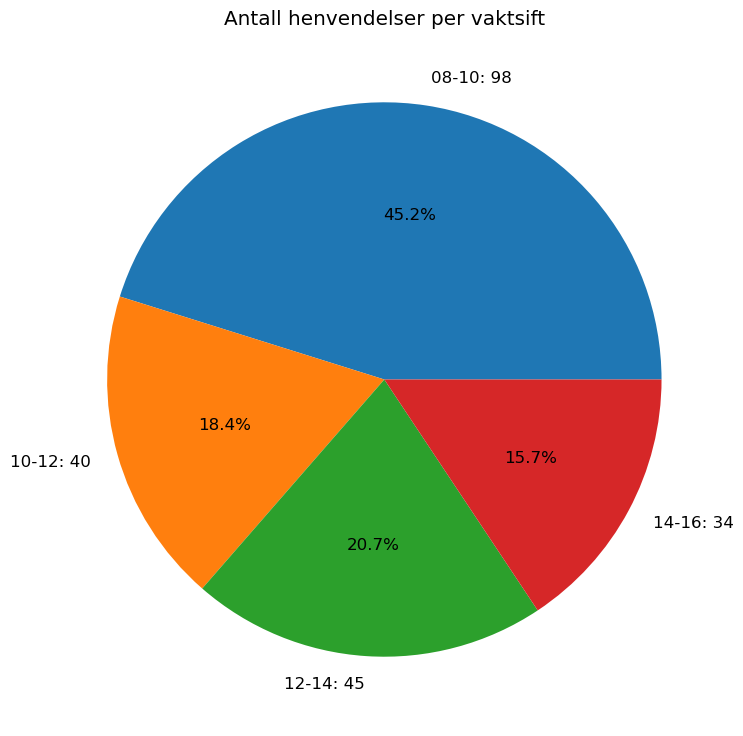

In [ ]:
##DEL E

# Filtrer til virkedager 
valid_days = {"Mandag", "Tirsdag", "Onsdag", "Torsdag", "Fredag"}
df = df[df["Ukedag"].isin(valid_days)]

#konverterer klokeslett til datetime for enkel timeuttrekking
df["Klokkeslett"] = pd.to_datetime(df["Klokkeslett"], format="%H:%M:%S", errors="coerce")
hours = df["Klokkeslett"].dt.hour

#lager vakt bøtt
def shift_bucket(h):
    if 8 <= h < 10:  return "08-10"
    if 10 <= h < 12: return "10-12"
    if 12 <= h < 14: return "12-14"
    if 14 <= h < 16: return "14-16"
    return None

vakt = hours.apply(shift_bucket)

# kalkulere henvendelser per vakt
order = ["08-10", "10-12", "12-14", "14-16"]
counts = vakt.value_counts().reindex(order, fill_value=0)

#pie visulazation  
data = counts.values
data_norm = data / sum(data)

my_labels = [
    f"08-10: {data[0]}",
    f"10-12: {data[1]}",
    f"12-14: {data[2]}",
    f"14-16: {data[3]}"]

plt.close('all')
plt.figure(1, figsize=(12, 9))
plt.rc('font', size=12)

plt.pie(data_norm, labels=my_labels, autopct='%.1f%%')
plt.title('Antall henvendelser per vaktsift')
plt.show()

In [ ]:
# gjør tilfredshetdatane til tall og fjern tomme verdier
score = pd.to_numeric(df["Tilfredshet"], errors="coerce").dropna()

# regner ut stor andel av kunde detractos,passives og promoters
detr = (score.between(1, 6)).mean() * 100     
neut = (score.between(7, 8)).mean() * 100     
prom = (score.between(9,10)).mean() * 100    

# Kalkulere selve NPS verdien
nps = prom - detr

print(f"Promoters (9-10): {prom:.1f}%")
print(f"Passives  (7-8):  {neut:.1f}%")
print(f"Detractors (1-6): {detr:.1f}%")
print(f"NPS: {nps:.1f}")

Promoters (9-10): 65.1%
Passives  (7-8):  11.6%
Detractors (1-6): 23.3%
NPS: 41.9
